# BREAST CANCER CLASSIFICATION

### Importing Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

### Dataset Loading

In [30]:
df = pd.read_csv(r"C:\Users\diyap\OneDrive\Desktop\Start\BreastCancer.csv.csv")

In [31]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Basic Data Check

In [32]:
 #STEP4: BASIC DATA CHECK
print("SHAPE:\n", df.shape)
print("\nINFO:\n")
print(df.info())
print("\nDESCRIBE:\n")
print(df.describe(include='all'))
print("\nCOLUMNS:\n")
print(df.columns)

SHAPE:
 (569, 33)

INFO:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  

In [33]:
 # STEP 5: CLEAN COLUMN NAMES
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'unnamed:_32'],
      dtype='object')

### Handling Missing Values

In [34]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave_points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave_points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave_points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
unnamed:

In [35]:
df.notnull().sum()

id                         569
diagnosis                  569
radius_mean                569
texture_mean               569
perimeter_mean             569
area_mean                  569
smoothness_mean            569
compactness_mean           569
concavity_mean             569
concave_points_mean        569
symmetry_mean              569
fractal_dimension_mean     569
radius_se                  569
texture_se                 569
perimeter_se               569
area_se                    569
smoothness_se              569
compactness_se             569
concavity_se               569
concave_points_se          569
symmetry_se                569
fractal_dimension_se       569
radius_worst               569
texture_worst              569
perimeter_worst            569
area_worst                 569
smoothness_worst           569
compactness_worst          569
concavity_worst            569
concave_points_worst       569
symmetry_worst             569
fractal_dimension_worst    569
unnamed:

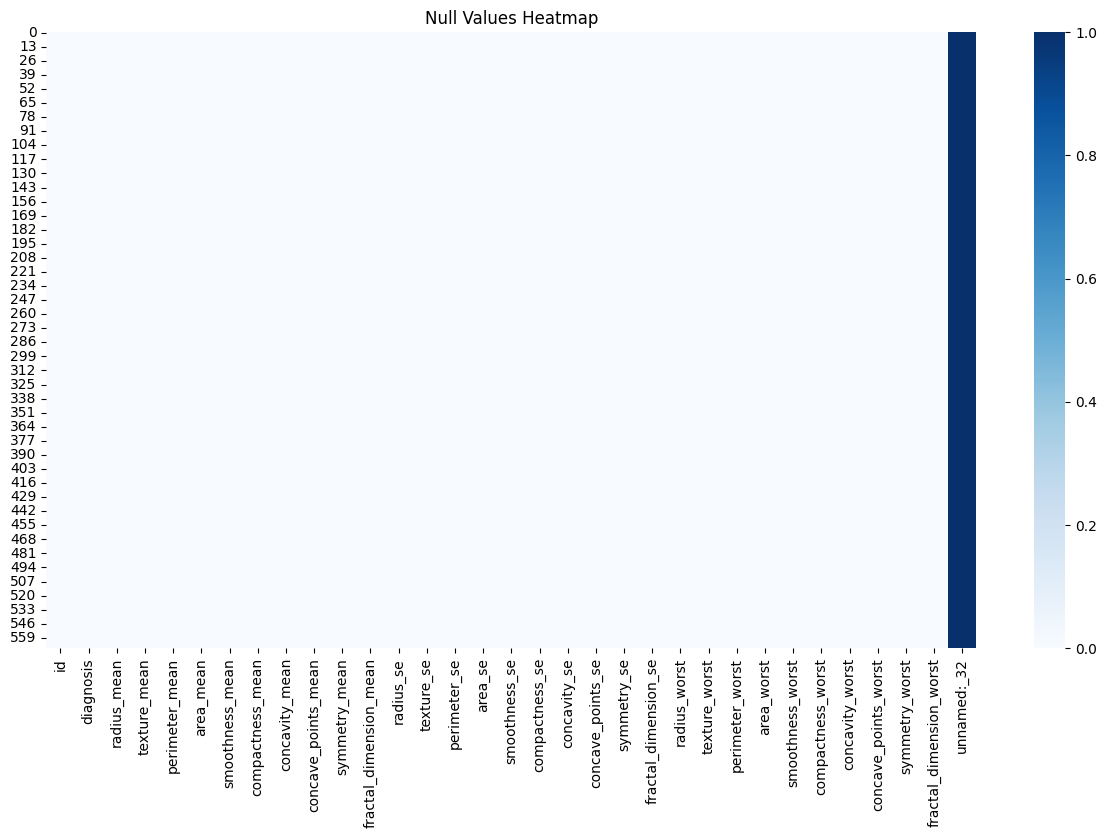

In [36]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), cmap="Blues", cbar=True)
plt.title("Null Values Heatmap")
plt.show()

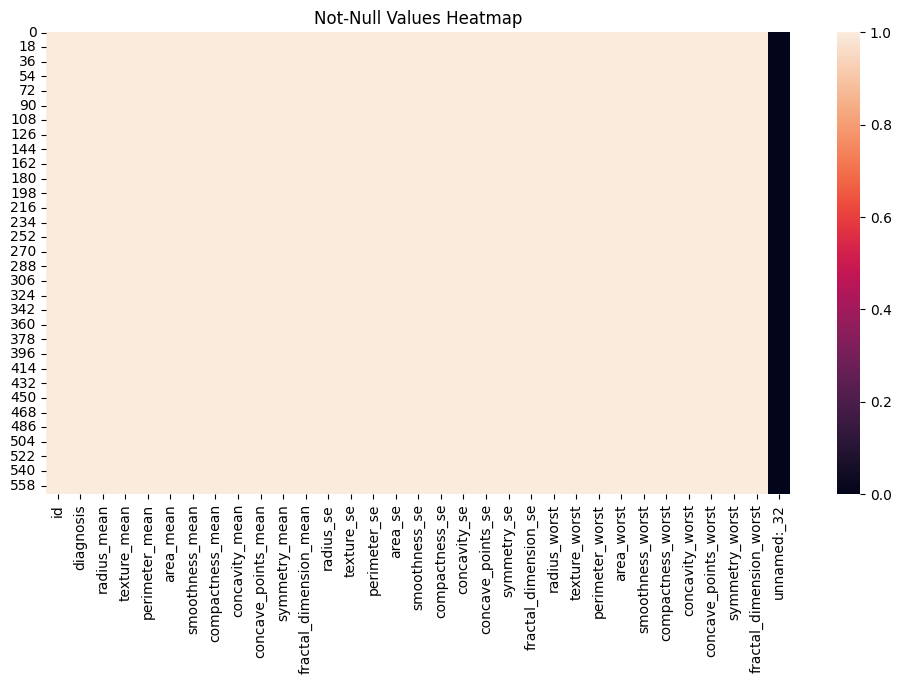

In [37]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.notnull(), cbar=True)
plt.title("Not-Null Values Heatmap")
plt.show()

### Handling Duplicate Values

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (569, 33)


### Fixing Data Types

In [40]:
df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [41]:
# RECHECK
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [42]:
# RECHECK
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave_points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave_points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave_points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
unnamed:

### Visualization

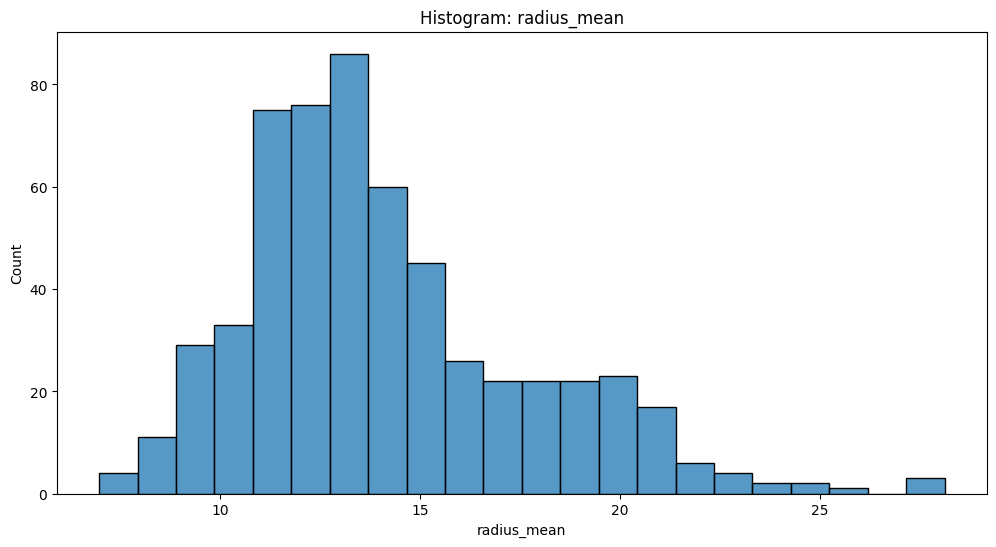

In [43]:
plt.figure(figsize=(12,6))
sns.histplot(df['radius_mean'])
plt.xlabel("radius_mean")
plt.ylabel("Count")
plt.title("Histogram: radius_mean")
plt.show()

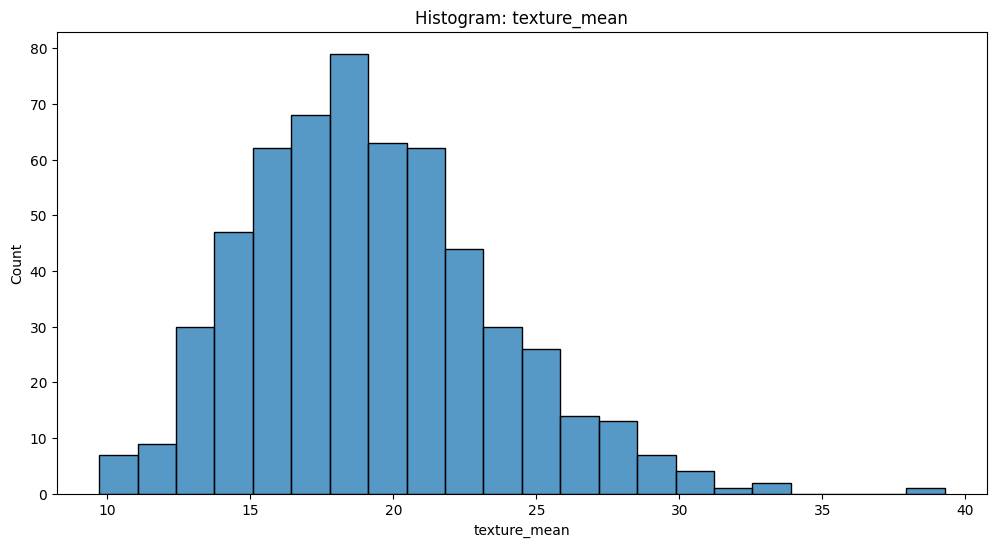

In [44]:
plt.figure(figsize=(12,6))
sns.histplot(df['texture_mean'])
plt.xlabel("texture_mean")
plt.ylabel("Count")
plt.title("Histogram: texture_mean")
plt.show()

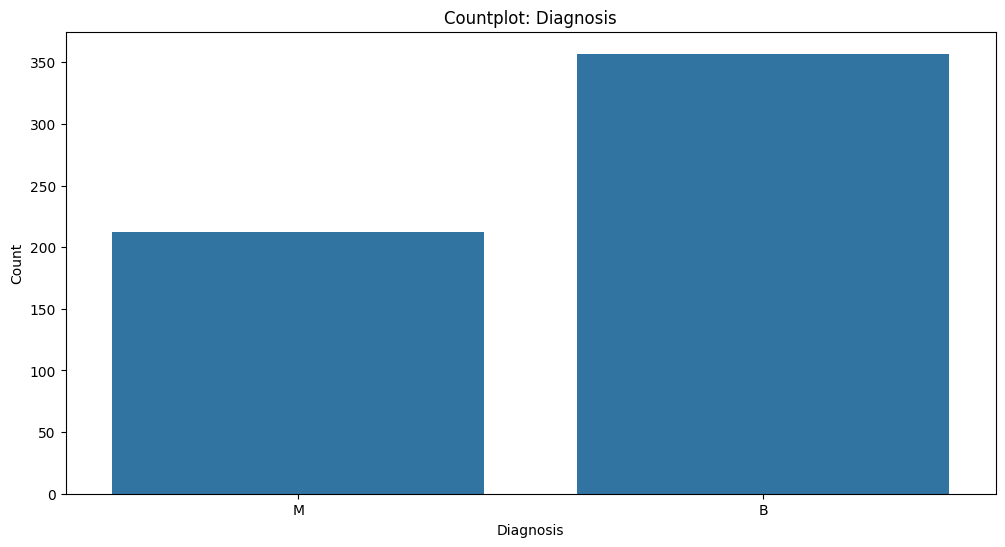

In [45]:
plt.figure(figsize=(12,6))
sns.countplot(x=df['diagnosis'])
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Countplot: Diagnosis")
plt.show()

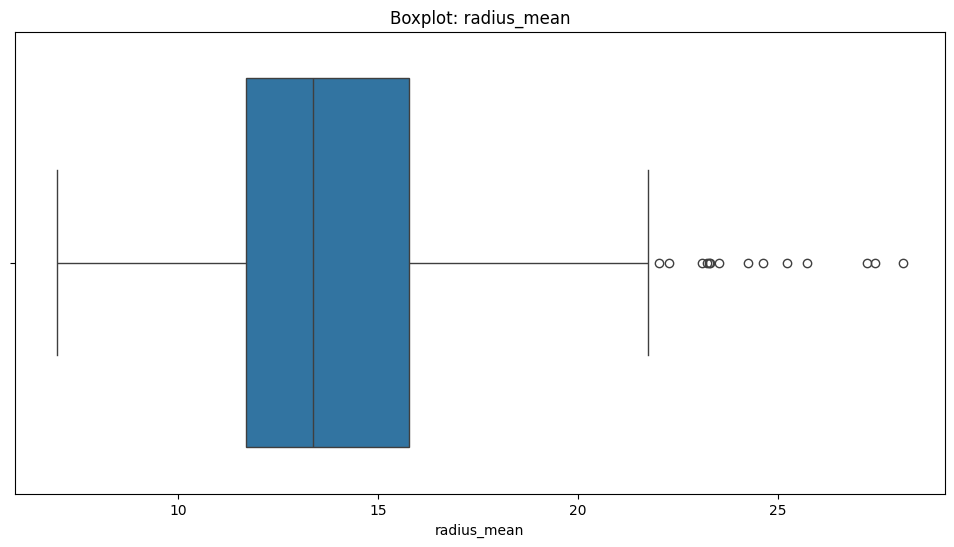

In [46]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df['radius_mean'])
plt.title("Boxplot: radius_mean")
plt.show()

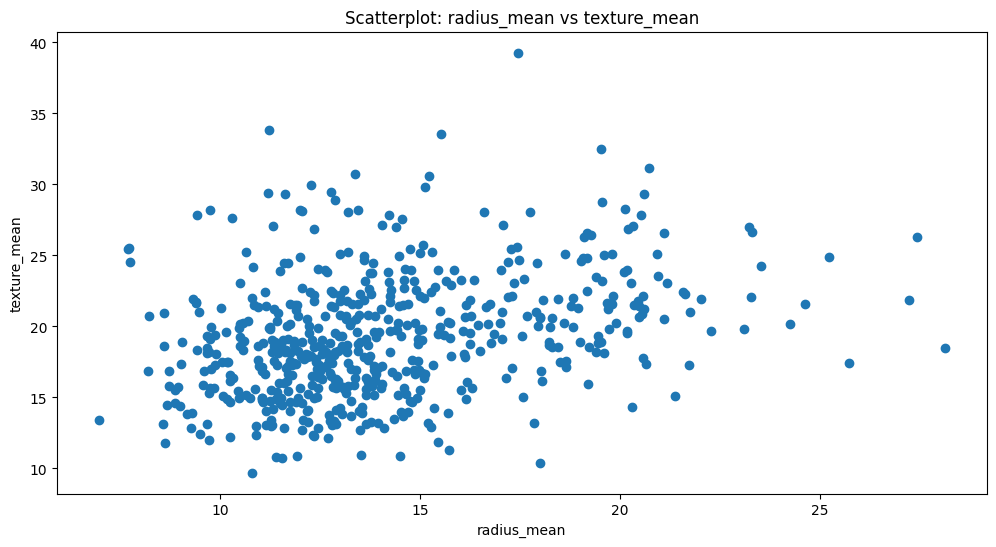

In [47]:
plt.figure(figsize=(12,6))
plt.scatter(df['radius_mean'], df['texture_mean'])
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("Scatterplot: radius_mean vs texture_mean")
plt.show()

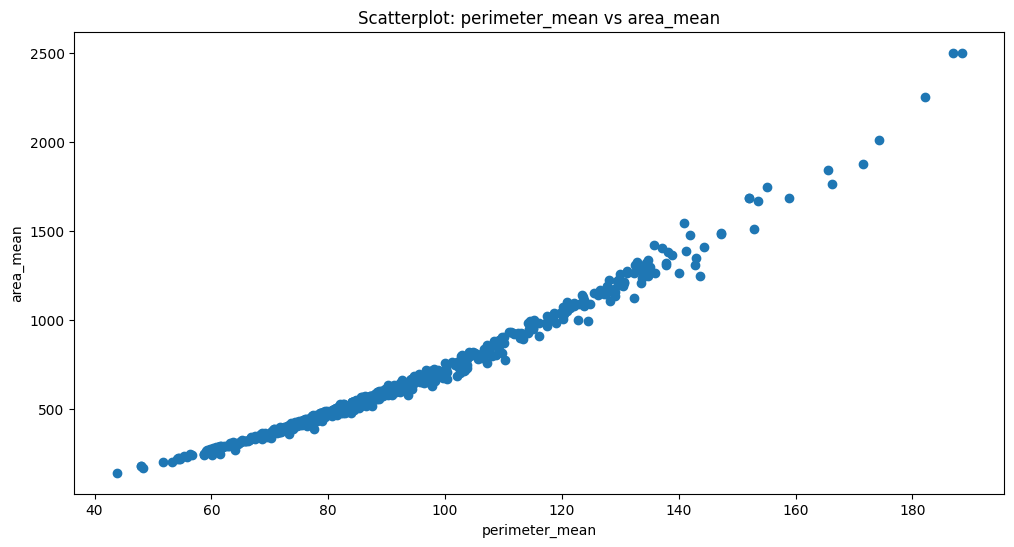

In [48]:
plt.figure(figsize=(12,6))
plt.scatter(df['perimeter_mean'], df['area_mean'])
plt.xlabel("perimeter_mean")
plt.ylabel("area_mean")
plt.title("Scatterplot: perimeter_mean vs area_mean")
plt.show()

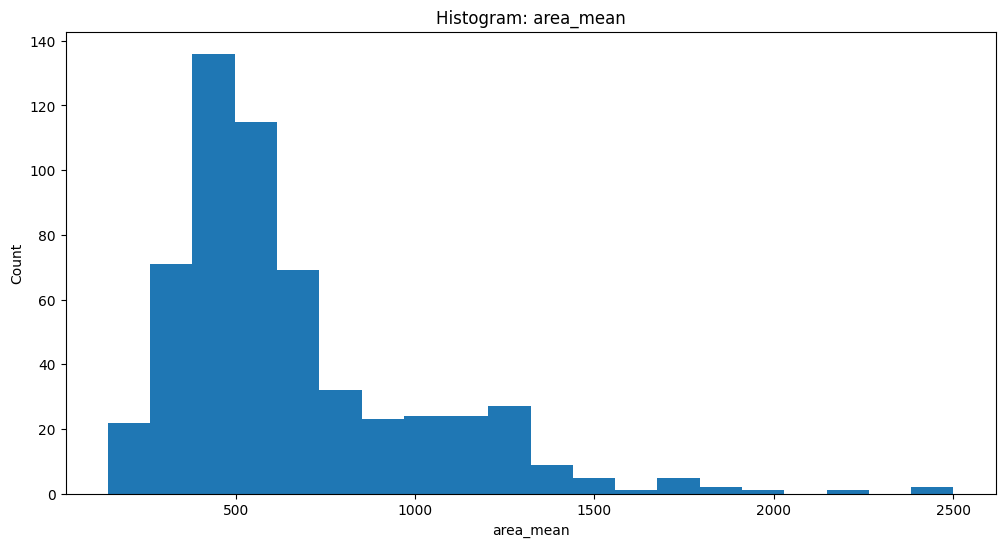

In [49]:
plt.figure(figsize=(12,6))
plt.hist(df['area_mean'], bins=20)
plt.xlabel("area_mean")
plt.ylabel("Count")
plt.title("Histogram: area_mean")
plt.show()

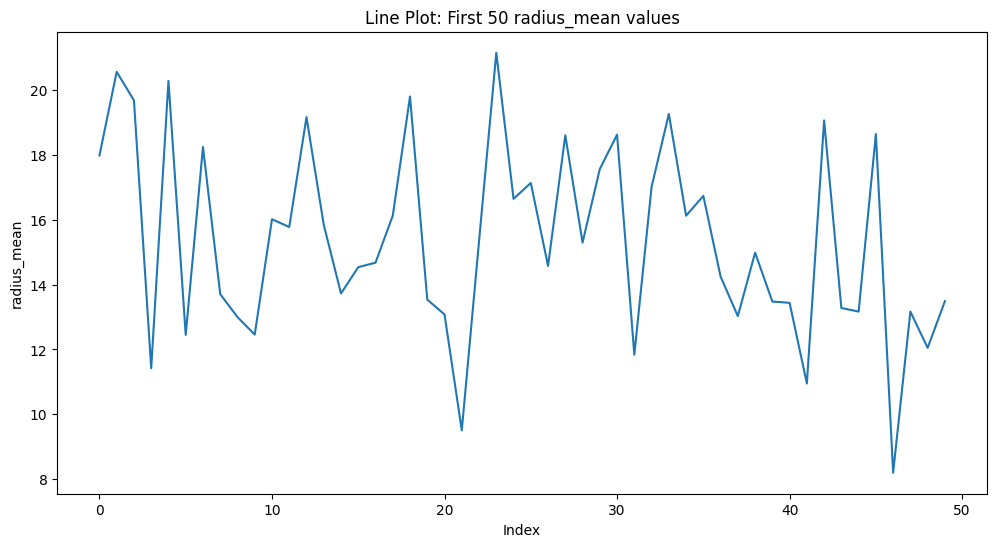

In [50]:
plt.figure(figsize=(12,6))
plt.plot(df['radius_mean'][:50])
plt.xlabel("Index")
plt.ylabel("radius_mean")
plt.title("Line Plot: First 50 radius_mean values")
plt.show()

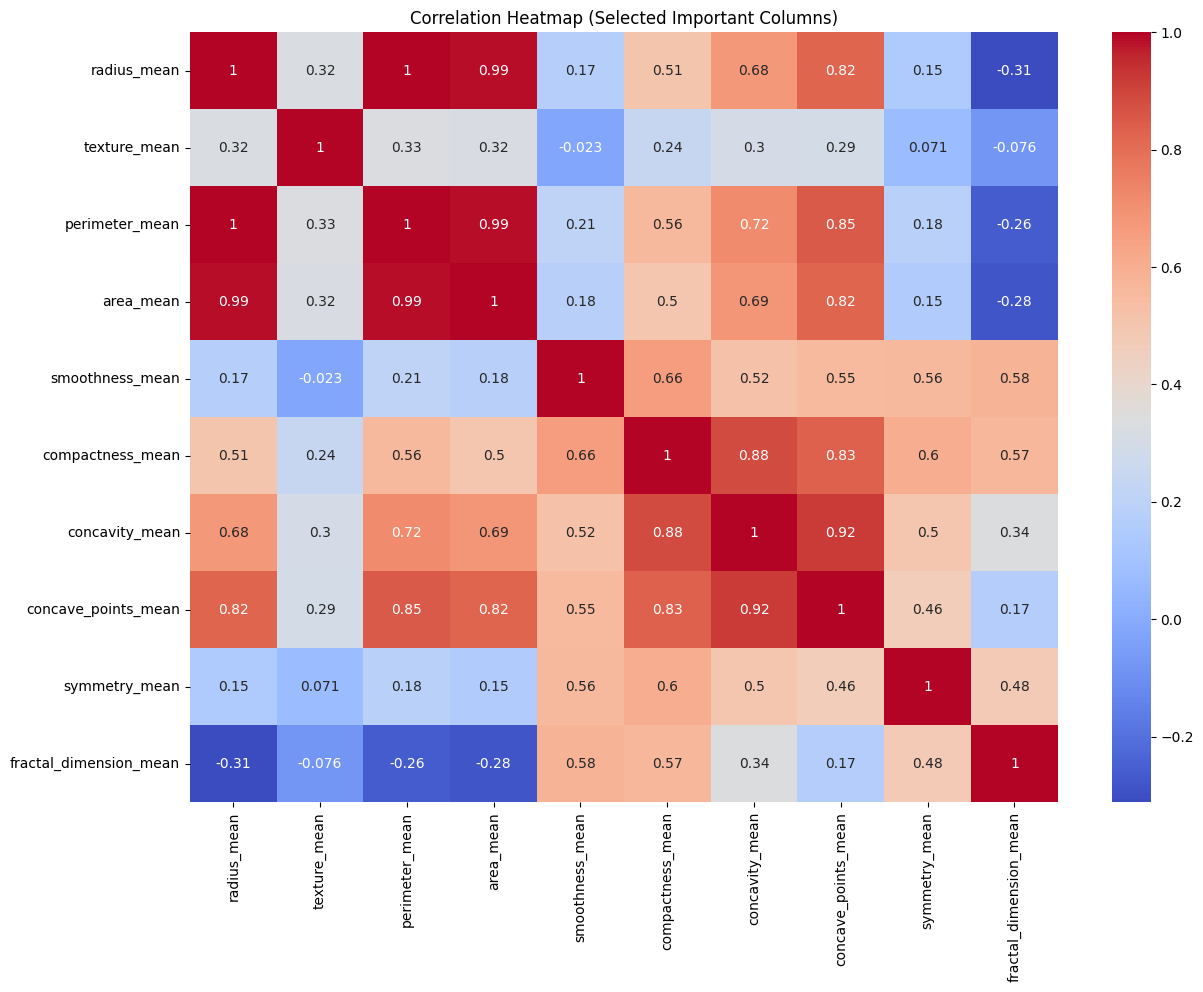

In [51]:
plt.figure(figsize=(14,10))
corr = df[['radius_mean','texture_mean','perimeter_mean','area_mean',
           'smoothness_mean','compactness_mean','concavity_mean',
           'concave_points_mean','symmetry_mean','fractal_dimension_mean']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Selected Important Columns)")
plt.show()

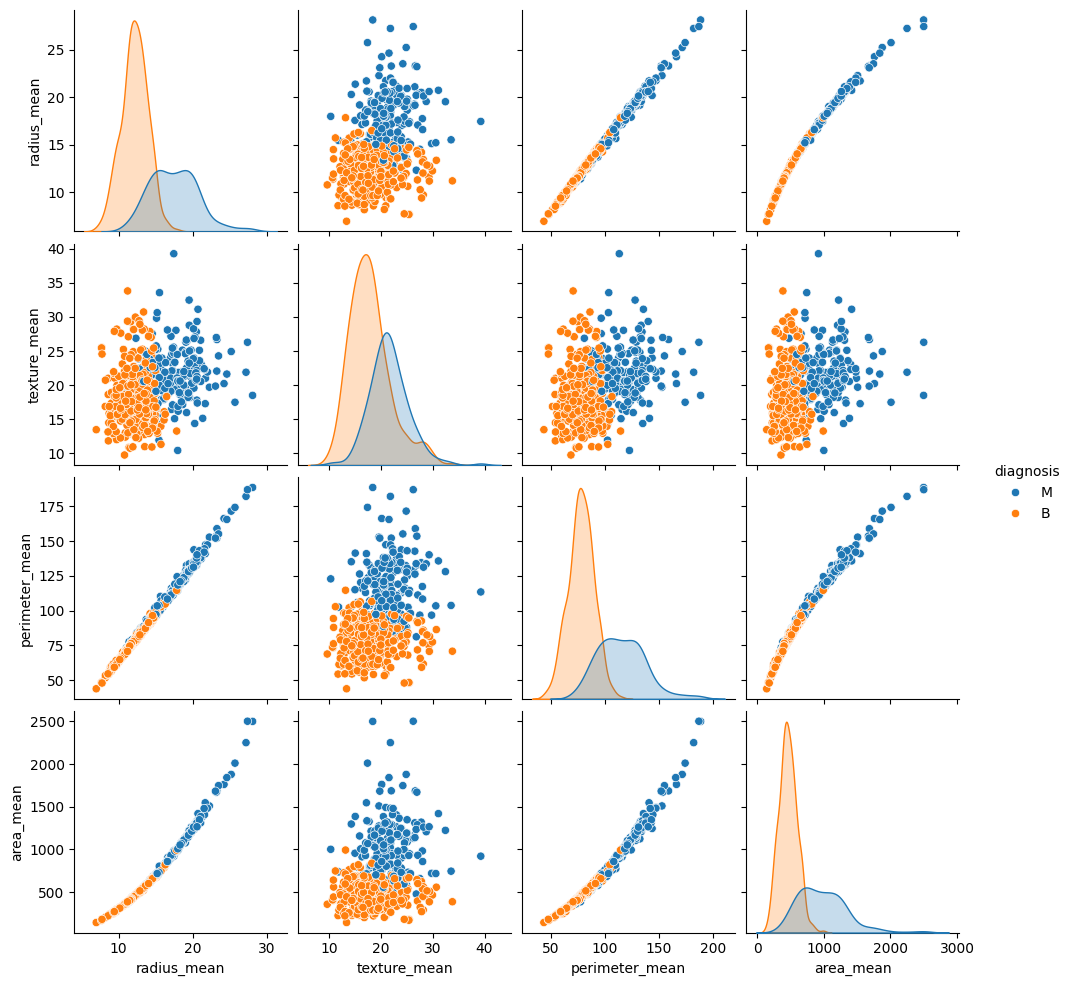

In [52]:
sns.pairplot(
    df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']],
    hue='diagnosis'
)
plt.show()

In [53]:
def cap_outliers(df_input, column_name):
    Q1 = df_input[column_name].quantile(0.25)
    Q3 = df_input[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_output = df_input[
        (df_input[column_name] >= lower_limit) &
        (df_input[column_name] <= upper_limit)
    ]

    return df_output


# Apply the function
df = cap_outliers(df, 'radius_mean')

### Draw Boxplot Again (After Handling Outliers)

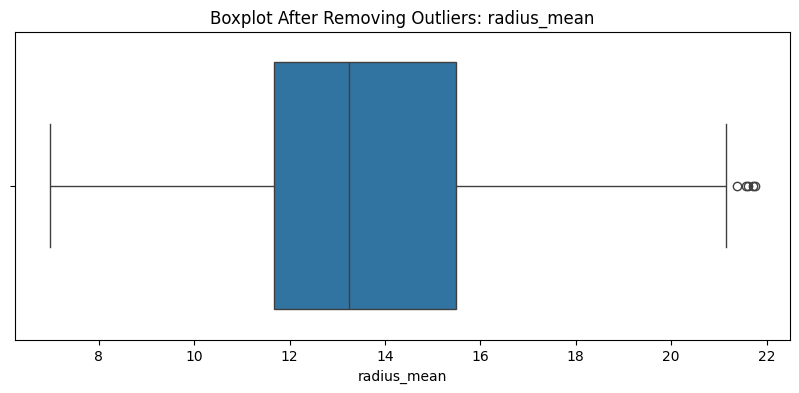

In [56]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['radius_mean'])
plt.title("Boxplot After Removing Outliers: radius_mean")
plt.show()

### Unique values in diagnosis

In [55]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

###  Value counts for diagnosis

In [57]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    198
Name: count, dtype: int64

In [58]:
# RE CHECK
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,unnamed:_32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2.MODELING

### LABEL ENCODING FOR TARGET

In [59]:
le = LabelEncoder()
df.loc[:, 'diagnosis'] = le.fit_transform(df['diagnosis'])

### FEATURE SELECTION

In [60]:
X = df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
        'smoothness_mean', 'compactness_mean', 'concavity_mean',
        'concave_points_mean', 'symmetry_mean',
        'fractal_dimension_mean']]

y = df['diagnosis'].astype(int)

### TRAIN–TEST SPLIT (80% TRAIN, 20% TEST)

In [61]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### SCALING

In [62]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### LOGISTIC REGRESSION

In [63]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
#Logistic Regression Training Accuracy
y_train_pred_lr = lr.predict(x_train)
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
print("Training Accuracy (LR):", train_acc_lr)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Training Accuracy (LR): 0.9459459459459459
Accuracy: 0.9009009009009009
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        65
           1       0.87      0.89      0.88        46

    accuracy                           0.90       111
   macro avg       0.90      0.90      0.90       111
weighted avg       0.90      0.90      0.90       111



### DECISIONTREE + HYPERPARAMETERTUNING

In [64]:
dt =DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred_dt =dt.predict(x_test)
#Decision TreeTraining Accuracy
y_train_pred_dt= dt.predict(x_train)
train_acc_dt =accuracy_score(y_train,y_train_pred_dt)
print("TrainingAccuracy(DT):",train_acc_dt)
print("Accuracy:",accuracy_score(y_test,y_pred_dt))
print(classification_report(y_test,y_pred_dt))
param_dt= {
'max_depth':[3,5,7],
'min_samples_split':[2,5,10]
}
grid_dt= GridSearchCV(DecisionTreeClassifier(),param_dt,cv=5)
grid_dt.fit(x_train, y_train)
print(grid_dt.best_params_)
print(grid_dt.best_score_)

TrainingAccuracy(DT): 1.0
Accuracy: 0.9009009009009009
              precision    recall  f1-score   support

           0       0.91      0.92      0.92        65
           1       0.89      0.87      0.88        46

    accuracy                           0.90       111
   macro avg       0.90      0.90      0.90       111
weighted avg       0.90      0.90      0.90       111

{'max_depth': 3, 'min_samples_split': 5}
0.9235188968335036


### RANDOM FOREST + HYPERPARAMETER TUNING

In [65]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
#Random Forest Training Accuracy
y_train_pred_rf = rf.predict(x_train)
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
print("Training Accuracy (RF):", train_acc_rf)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
param_rf = {
'n_estimators':[50,100],
'max_depth':[5,10,None]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=5)
grid_rf.fit(x_train, y_train)
print(grid_rf.best_params_)
print(grid_rf.best_score_)

Training Accuracy (RF): 1.0
Accuracy: 0.9009009009009009
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        65
           1       0.86      0.91      0.88        46

    accuracy                           0.90       111
   macro avg       0.90      0.90      0.90       111
weighted avg       0.90      0.90      0.90       111

{'max_depth': 5, 'n_estimators': 100}
0.9460418794688458


### KNN + HYPERPARAMETER TUNING

In [66]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
#KNN Training Accuracy
y_train_pred_knn = knn.predict(x_train)
train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
print("Training Accuracy (KNN):", train_acc_knn)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
param_knn = {
'n_neighbors':[3,5,7],
'metric':['euclidean','manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)
grid_knn.fit(x_train, y_train)
print(grid_knn.best_params_)
print(grid_knn.best_score_)

Training Accuracy (KNN): 0.9504504504504504
Accuracy: 0.8738738738738738
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        65
           1       0.82      0.89      0.85        46

    accuracy                           0.87       111
   macro avg       0.87      0.88      0.87       111
weighted avg       0.88      0.87      0.87       111

{'metric': 'euclidean', 'n_neighbors': 5}
0.9370275791624106


### FINAL ACCURACY SUMMARY

In [67]:
print("\n FINAL MODEL ACCURACY SUMMARY")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_knn))


 FINAL MODEL ACCURACY SUMMARY
Logistic Regression: 0.9009009009009009
Decision Tree: 0.9009009009009009
Random Forest: 0.9009009009009009
KNN: 0.8738738738738738


### STORE MODEL ACCURACIES

In [68]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_knn = accuracy_score(y_test, y_pred_knn)

### MODEL ACCURACY COMPARISON

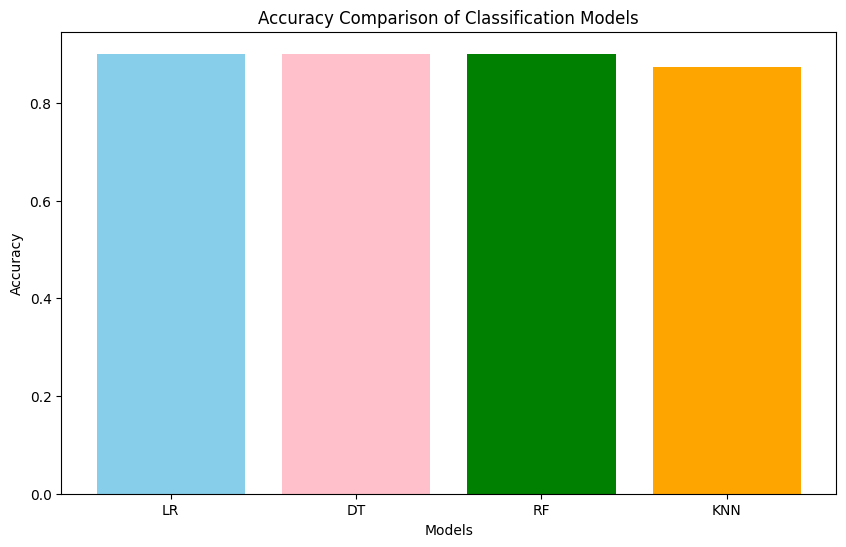

In [69]:
models = ['LR', 'DT', 'RF', 'KNN']
accuracies = [acc_lr, acc_dt, acc_rf, acc_knn]
plt.figure(figsize=(10,6))
plt.bar(models, accuracies, color=['skyblue','pink','green','orange'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")
plt.show()

### TEST ACCURACIES

In [70]:
test_acc_lr = accuracy_score(y_test, y_pred_lr)
test_acc_dt = accuracy_score(y_test, y_pred_dt)
test_acc_rf = accuracy_score(y_test, y_pred_rf)
test_acc_knn = accuracy_score(y_test, y_pred_knn)
print("\nTesting Accuracies:")
print("LR:", test_acc_lr)
print("DT:", test_acc_dt)
print("RF:", test_acc_rf)
print("KNN:", test_acc_knn)


Testing Accuracies:
LR: 0.9009009009009009
DT: 0.9009009009009009
RF: 0.9009009009009009
KNN: 0.8738738738738738


### TEST ACCURACY COMPARISON

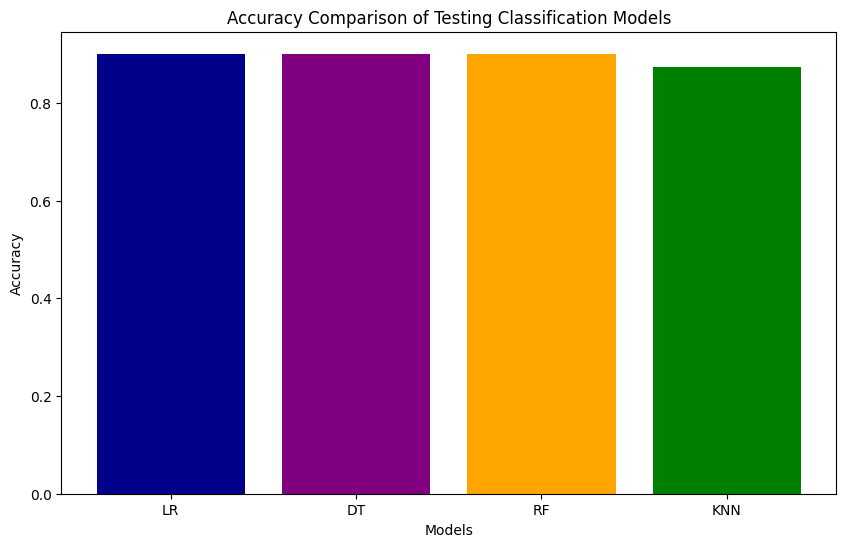

In [71]:
models = ['LR', 'DT', 'RF', 'KNN']
accuracies = [test_acc_lr,test_acc_dt, test_acc_rf,test_acc_knn]
plt.figure(figsize=(10,6))
plt.bar(models, accuracies, color=['Darkblue','purple','orange','green'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Testing Classification Models")
plt.show()

#### ~Insights (Based on model Accuracies)
1. Decision Tree has the highest accuracy (0.9189).-It performed the best among all four models in this dataset.
2. Logistic Regression and Random Forest have the same accuracy (0.9009).
-Both models give strong performance and are very close to the best model.
3. KNN has the lowest accuracy (0.8739).-KNN is more sensitive to scaling and noise, so its accuracy is a bit lower.
#### ~Insights (Based on model testing Accuracies)
1. Random Forest (RF) is the best-performing model (0.9099)-It is an ensemble model (multiple trees → better generalization)-It reduces overfitting compared to a single Decision Tree
2. KNN performs the lowest (0.8738)-Very sensitive to noise